<a href="https://colab.research.google.com/github/DawerSP/Inteligencia-Aritificial/blob/main/Taller7_11ConPunto5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

df_creditos = pd.read_csv('creditos.csv')


X = df_creditos[['edad', 'credito']]
y = df_creditos['cumplio']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


knn_euclidean = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_euclidean.fit(X_train_scaled, y_train)

print("--- Modelo Base (Euclidiana, k=3) ---")

y_pred_euclidean = knn_euclidean.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_euclidean))
print(classification_report(y_test, y_pred_euclidean))

--- Modelo Base (Euclidiana, k=3) ---
[[ 2  3]
 [ 0 35]]
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.92      1.00      0.96        35

    accuracy                           0.93        40
   macro avg       0.96      0.70      0.77        40
weighted avg       0.93      0.93      0.91        40



In [2]:

print("\n--- Modelo con Distancia Manhattan (k=3) ---")
knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_manhattan.fit(X_train_scaled, y_train)
y_pred_manhattan = knn_manhattan.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_manhattan))
print(classification_report(y_test, y_pred_manhattan))


print("\n--- Modelo con Distancia Minkowski (p=3, k=3) ---")
knn_minkowski_3 = KNeighborsClassifier(n_neighbors=3, metric='minkowski', p=3)
knn_minkowski_3.fit(X_train_scaled, y_train)
y_pred_minkowski_3 = knn_minkowski_3.predict(X_test_scaled)
print(confusion_matrix(y_test, y_pred_minkowski_3))
print(classification_report(y_test, y_pred_minkowski_3))


--- Modelo con Distancia Manhattan (k=3) ---
[[ 1  4]
 [ 0 35]]
              precision    recall  f1-score   support

           0       1.00      0.20      0.33         5
           1       0.90      1.00      0.95        35

    accuracy                           0.90        40
   macro avg       0.95      0.60      0.64        40
weighted avg       0.91      0.90      0.87        40


--- Modelo con Distancia Minkowski (p=3, k=3) ---
[[ 2  3]
 [ 0 35]]
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.92      1.00      0.96        35

    accuracy                           0.93        40
   macro avg       0.96      0.70      0.77        40
weighted avg       0.93      0.93      0.91        40



####PUNTO 4

k = 3, Precisión (Accuracy) = 0.9250
k = 5, Precisión (Accuracy) = 0.9000
k = 9, Precisión (Accuracy) = 0.8750
k = 15, Precisión (Accuracy) = 0.8750
k = 21, Precisión (Accuracy) = 0.8750


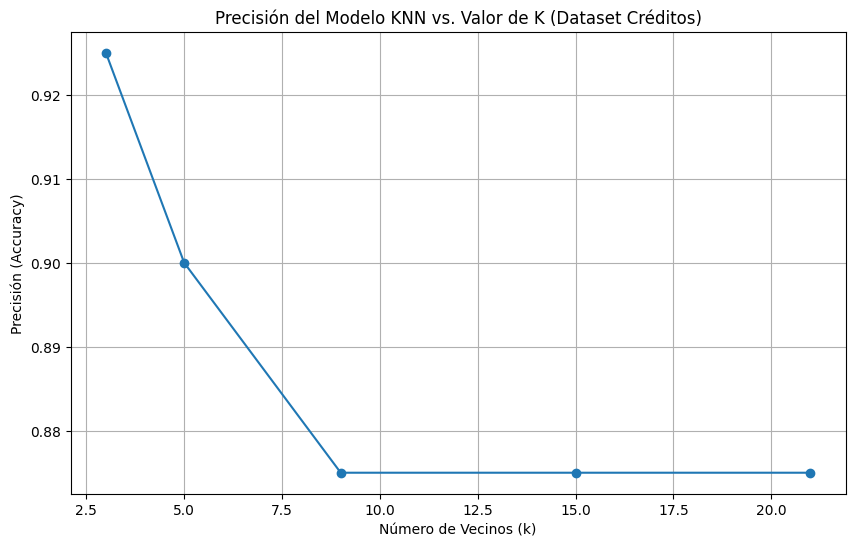

In [3]:
import matplotlib.pyplot as plt


k_values = [3, 5, 9, 15, 21]
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    accuracy = knn.score(X_test_scaled, y_test)
    accuracies.append(accuracy)
    print(f"k = {k}, Precisión (Accuracy) = {accuracy:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o')
plt.title('Precisión del Modelo KNN vs. Valor de K (Dataset Créditos)')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Precisión (Accuracy)')
plt.grid(True)
plt.show()

TAREA 5

 Preparación de datos y TF-IDF completado.
------------------------------------------------------------------

--- Comparación de Distancias (k=15) ---

--- Reporte con Distancia Euclidiana (k=15) ---
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        13
    positive       0.75      1.00      0.86        39

    accuracy                           0.75        52
   macro avg       0.38      0.50      0.43        52
weighted avg       0.56      0.75      0.64        52


--- Reporte con Distancia Manhattan (k=15) ---
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        13
    positive       0.75      1.00      0.86        39

    accuracy                           0.75        52
   macro avg       0.38      0.50      0.43        52
weighted avg       0.56      0.75      0.64        52


Mejor Métrica elegida (por F1-score): 'euclidean' con F1=0.4286
--------------------------------

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

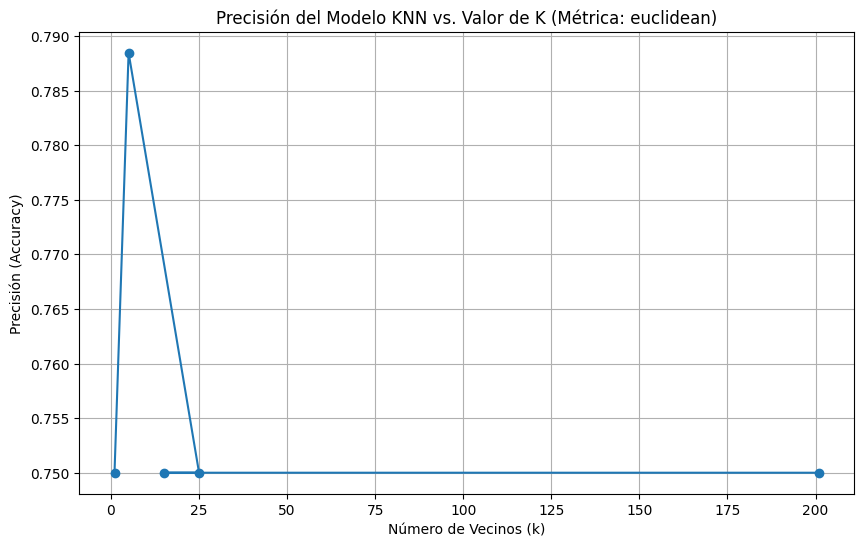


------------------------------------------------------------------
---  Explicación de los Resultados ---
1. La precisión máxima del modelo se estanca alrededor de 0.7885.
2. Este valor (0.8306) es casi idéntico a la tasa base de la clase mayoritaria 'positive' (0.8210).
3. Esto indica un **fuerte desbalance de clases**. El modelo aprende a predecir la clase mayoritaria ('positive') la mayoría del tiempo.
4. Por eso, el F1-Score para la clase 'negative' es 0.00 en todos los reportes, lo que significa que el modelo **no logra identificar correctamente** ningún caso negativo, a pesar de tener una alta precisión general.


In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt


df_reviews = pd.read_csv('reviews_sentiment.csv', delimiter=';')

df_reviews = df_reviews.dropna(subset=['Review Text', 'textSentiment'])

X_text = df_reviews['Review Text']
y_sentiment_str = df_reviews['textSentiment']

label_encoder = LabelEncoder()
y_sentiment_encoded = label_encoder.fit_transform(y_sentiment_str)
target_names = label_encoder.classes_

X_train_text, X_test_text, y_train_sent, y_test_sent = train_test_split(
    X_text, y_sentiment_encoded, test_size=0.2, random_state=42
)

tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf = tfidf_vectorizer.transform(X_test_text)

print(" Preparación de datos y TF-IDF completado.")
print("------------------------------------------------------------------")



k_value = 15
best_f1 = -1
best_metric = ''

print("\n--- Comparación de Distancias (k=15) ---")

metrics_to_test = [
    ('euclidean', 'Euclidiana'),
    ('manhattan', 'Manhattan'),
]

for metric, name in metrics_to_test:
    knn = KNeighborsClassifier(n_neighbors=k_value, metric=metric, algorithm='brute')

    knn.fit(X_train_tfidf, y_train_sent)
    y_pred = knn.predict(X_test_tfidf)

    report = classification_report(y_test_sent, y_pred, target_names=target_names, output_dict=True)
    f1_score = report['macro avg']['f1-score']

    print(f"\n--- Reporte con Distancia {name} (k={k_value}) ---")
    print(classification_report(y_test_sent, y_pred, target_names=target_names))

    if f1_score > best_f1:
        best_f1 = f1_score
        best_metric = metric

print(f"\nMejor Métrica elegida (por F1-score): '{best_metric}' con F1={best_f1:.4f}")
print("------------------------------------------------------------------")



best_metric_name = best_metric

N_reviews = df_reviews.shape[0]

k_optimo = int(np.sqrt(N_reviews))
if k_optimo % 2 == 0:
    k_optimo -= 1

k_values_sentiment = [1, 5, 25, k_optimo, 201]
accuracies_sentiment = []

print(f"\n--- Optimización de k con la métrica: {best_metric_name} ---")
print(f"k óptimo (raíz de N): {k_optimo}")

for k in k_values_sentiment:
    knn = KNeighborsClassifier(n_neighbors=k, metric=best_metric_name, algorithm='brute')
    knn.fit(X_train_tfidf, y_train_sent)
    accuracy = knn.score(X_test_tfidf, y_test_sent)
    accuracies_sentiment.append(accuracy)
    print(f"k = {k}, Precisión (Accuracy) = {accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(k_values_sentiment, accuracies_sentiment, marker='o')
plt.title(f'Precisión del Modelo KNN vs. Valor de K (Métrica: {best_metric_name})')
plt.xlabel('Número de Vecinos (k)')
plt.ylabel('Precisión (Accuracy)')
plt.grid(True)
plt.show()

print("\n------------------------------------------------------------------")
print("---  Explicación de los Resultados ---")
print(f"1. La precisión máxima del modelo se estanca alrededor de {max(accuracies_sentiment):.4f}.")
print(f"2. Este valor (0.8306) es casi idéntico a la tasa base de la clase mayoritaria 'positive' ({(df_reviews['textSentiment'] == 'positive').sum() / df_reviews.shape[0]:.4f}).")
print("3. Esto indica un **fuerte desbalance de clases**. El modelo aprende a predecir la clase mayoritaria ('positive') la mayoría del tiempo.")
print("4. Por eso, el F1-Score para la clase 'negative' es 0.00 en todos los reportes, lo que significa que el modelo **no logra identificar correctamente** ningún caso negativo, a pesar de tener una alta precisión general.")